In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


/tmp/ipykernel_26037/4194713879.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
front_view_velocity_path = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/velocity_data_autogrid_front_vid_2025-07-21_19-28-45_using_full_profile.csv"
side_view_velocity_path = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/velocity_data_autogrid_side_vid_2025-07-21_19-25-39_using_full_profile.csv"

In [3]:
front_view_data = pd.read_csv(front_view_velocity_path)
side_view_data = pd.read_csv(side_view_velocity_path)
# combine the data with a heading to indicate the view
front_view_data['view'] = 'front'
side_view_data['view'] = 'side'
# concatenate the two dataframes
combined_data = pd.concat([front_view_data, side_view_data], ignore_index=True)
pixel_correction_factor = 149/123
combined_data['depth_mm'] = combined_data['depth_mm'] / pixel_correction_factor
combined_data['depth_mm_from_midpoint'] = combined_data['depth_mm'] + 1
front_view_data['depth_mm_from_midpoint'] = front_view_data['depth_mm'] + 1
front_view_data['depth_mm_from_maximum'] = front_view_data['depth_mm'] + 2 
front_view_data['model_velocity_using_midpoint'] = np.sqrt(2 * 9.81 * front_view_data['depth_mm_from_midpoint'] * 1e-3)
front_view_data['model_velocity_from_maximum'] = np.sqrt(2 * 9.81 * front_view_data['depth_mm_from_maximum'] * 1e-3)
front_view_data['model_velocity_from_minimum'] = np.sqrt(2 * 9.81 * (front_view_data['depth_mm']) * 1e-3)
combined_data.head()

,depth_mm,velocity_m_per_s,quality_of_fit,model_velocity_m_per_s,view,depth_mm_from_midpoint
0,0.206376,-4.156085e-02,0.883929,0.070036,front,1.206376
1,0.247651,-1.952101e-02,0.730243,0.076720,front,1.247651
2,0.288926,-9.445648e-03,0.535714,0.082867,front,1.288926
3,0.330201,6.739781e-17,1.000000,0.088589,front,1.330201
4,0.371477,2.959636e-02,0.928151,0.093963,front,1.371477


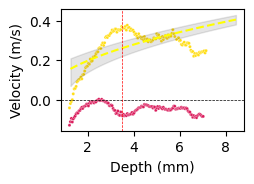

In [4]:
import seaborn as sns
figsize_mm = (60, 40)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig, ax = plt.subplots(figsize=figsize_inch)
# plot the data
sns.scatterplot(data=combined_data, x='depth_mm_from_midpoint', y='velocity_m_per_s', hue='view', ax=ax, s=5, legend=False, palette={"front": "#ffde17", "side": "#da1c5c"})
sns.lineplot(data=front_view_data, x="depth_mm_from_midpoint", y="model_velocity_using_midpoint", ax=ax, linestyle='--', color='yellow', legend=False)
# add a shaded region between two model velocities
ax.fill_between(front_view_data['depth_mm_from_midpoint'], 
                front_view_data['model_velocity_from_maximum'], 
                front_view_data['model_velocity_from_minimum'], 
                color='black', alpha=0.1, label='Model Velocity Range')
# set the x and y axis labels
ax.set_xlabel('Depth (mm)')
ax.set_ylabel('Velocity (m/s)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
pinch_off_point = 3.5
ax.axvline(pinch_off_point, color='red', linewidth=0.5, linestyle='--', label='Pinch-off Point')
fig_save_path = os.path.join(os.path.dirname(front_view_velocity_path), 'combined_velocity_plot_pixel_corrected_yellow_red.pdf')
#fig.savefig(fig_save_path, bbox_inches='tight', dpi=600)


In [5]:
combined_data

,depth_mm,velocity_m_per_s,quality_of_fit,model_velocity_m_per_s,view,depth_mm_from_midpoint
0,0.206376,-4.156085e-02,0.883929,0.070036,front,1.206376
1,0.247651,-1.952101e-02,0.730243,0.076720,front,1.247651
2,0.288926,-9.445648e-03,0.535714,0.082867,front,1.288926
3,0.330201,6.739781e-17,1.000000,0.088589,front,1.330201
4,0.371477,2.959636e-02,0.928151,0.093963,front,1.371477
...,...,...,...,...,...,...
280,5.861074,-7.304635e-02,0.889947,0.373232,side,6.861074
281,5.902349,-7.556519e-02,0.938478,0.374544,side,6.902349
282,5.943624,-8.060287e-02,0.930275,0.375851,side,6.943624
283,5.984899,-8.564055e-02,0.968580,0.377154,side,6.984899


In [5]:
# front_position_data_at_pinch_off = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/fig_data_at_depth_2.7999999999999994_autogrid_front_vid_2025-07-21_19-28-45.json"
# side_position_data_at_pinch_off = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/fig_data_at_depth_2.7999999999999994_autogrid_side_vid_2025-07-21_19-25-39.json"
# front_position_data = pd.read_json(front_position_data_at_pinch_off)
# side_position_data = pd.read_json(side_position_data_at_pinch_off)
# # shift times to start from zero for both views
# front_position_data['times'] -= front_position_data['times'].min()
# side_position_data['times'] -= side_position_data['times'].min()
# # shift positions to start from zero for both views
# front_position_data['positions'] -= front_position_data['positions'].iloc[0]
# side_position_data['positions'] -= side_position_data['positions'].iloc[0]

# # combine the data with a heading to indicate the view
# front_position_data['view'] = 'front'
# side_position_data['view'] = 'side'
# # concatenate the two dataframes
# combined_position_data = pd.concat([front_position_data, side_position_data], ignore_index=True)
# combined_position_data["times_ms"] = combined_position_data["times"] * 1000  # convert to milliseconds
# combined_position_data["positions_mm"] = combined_position_data["positions"] * 1000  # convert to mm
# combined_position_data.head()

,times,positions,velocities,depth_mm,view,times_ms,positions_mm
0,0.000000,0.000000,2.979787,2.8,front,0.000000,0.0000
1,0.000185,0.000551,1.891019,2.8,front,0.184980,0.5512
2,0.000370,0.000700,1.031465,2.8,front,0.369959,0.6996
3,0.000555,0.000933,1.088768,2.8,front,0.554939,0.9328
4,0.000740,0.001102,0.916858,2.8,front,0.739919,1.1024
